# State-update backend example

This notebook walks through an end-to-end workflow with the `state_update`
backend: compile a cyclic graph, train a small model, and interpret named
nodes.

It assumes you have already read the [Getting started](../getting-started/)
notebook. That tutorial covers package basics, feature alignment, and the
overall `edge2torch` workflow. Here we focus on what changes when the graph
contains cycles and the model is compiled as a fixed-step state-update
network.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from torch import nn

import edge2torch as e2t

sns.set_theme(style="whitegrid")

## Define a cyclic graph

The `state_update` backend allows cycles among internal nodes. In this
toy example, two hidden nodes exchange feedback while input features
feed each node:

- `input_signal` is the input to `node_a`
- `input_noise` is the input to `node_b`
- `node_a` and `node_b` form a feedback loop
- `node_a` connects to the output node `output`

The first walkthrough below uses only `input_signal` as informative. A
later section repeats the same architecture under positive and negative
controls that vary which inputs carry signal.

In [2]:
edgelist = pd.DataFrame(
    {
        "source": [
            "input_signal",
            "input_noise",
            "node_a",
            "node_b",
            "node_a",
        ],
        "target": [
            "node_a",
            "node_b",
            "node_b",
            "node_a",
            "output",
        ],
    }
)

edgelist

,source,target
0,input_signal,node_a
1,input_noise,node_b
2,node_a,node_b
3,node_b,node_a
4,node_a,output


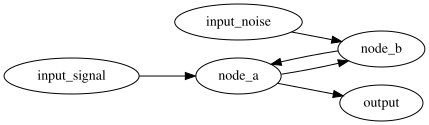

In [3]:
dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = ["input_signal", "input_noise"]
state_nodes = ["node_a", "node_b"]
output_nodes = ["output"]

for node_name in input_nodes:
    dot.node(node_name, node_name)

for node_name in state_nodes:
    dot.node(node_name, node_name)

for node_name in output_nodes:
    dot.node(node_name, node_name)

for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))

dot

## Compile with backend="state_update"

Use the `steps` argument to control how many state-update steps are unrolled
during compilation. Node interpretation sites are exposed as `step_1`,
`step_2`, and so on.

In [4]:
model, artifact = e2t.compile_graph(
    edgelist=edgelist,
    backend="state_update",
    steps=2,
    quiet=True,
)

artifact.backend, list(artifact.interpretation_sites.keys())

('state_update', ['step_1', 'step_2'])

## Simulate data, align features, and train

In [5]:
def simulate_binary_data(
    n_per_class,
    feature_names,
    informative_features,
    rng,
):
    n_features = len(feature_names)
    n_samples = 2 * n_per_class

    x = rng.normal(0.0, 1.0, size=(n_samples, n_features))
    y = np.array([0] * n_per_class + [1] * n_per_class)

    informative_idx = [
        feature_names.index(feature_name)
        for feature_name in informative_features
    ]

    for class_value, shift in enumerate([-1.5, 1.5]):
        class_mask = y == class_value
        for feature_idx in informative_idx:
            x[class_mask, feature_idx] += shift

    x_df = pd.DataFrame(x, columns=feature_names)
    y_series = pd.Series(y, name="label")

    return x_df, y_series

In [6]:
rng = np.random.default_rng(0)

x_train_df, y_train = simulate_binary_data(
    n_per_class=80,
    feature_names=artifact.feature_names,
    informative_features=["input_signal"],
    rng=rng,
)

x_test_df, y_test = simulate_binary_data(
    n_per_class=40,
    feature_names=artifact.feature_names,
    informative_features=["input_signal"],
    rng=rng,
)

x_train_df.head()

,input_noise,input_signal
0,0.125730,-1.632105
1,0.640423,-1.395100
2,-0.535669,-1.138405
3,1.304000,-0.552919
4,-0.703735,-2.765421


Loss before first update: 0.7288
Loss after final update:  0.1973


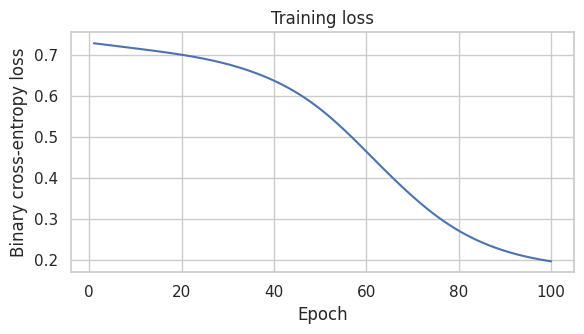

In [7]:
torch.manual_seed(0)

x_train = e2t.align_features_to_input_nodes(
    data=x_train_df,
    artifact=artifact,
)
x_test = e2t.align_features_to_input_nodes(
    data=x_test_df,
    artifact=artifact,
)

customized_model = e2t.customize_model(
    model=model,
    head=nn.Linear(1, 1),
)

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(customized_model.parameters(), lr=1e-2)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 100
loss_history = []

customized_model.train()

for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = customized_model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print("Loss before first update:", round(loss_history[0], 4))
print("Loss after final update: ", round(loss_history[-1], 4))

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, n_epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Interpret nodes

This first walkthrough is the A-only setting: only `input_signal` is
informative.

By default, `interpret_model(..., target="nodes")` returns one summary
`pandas.DataFrame` with hidden nodes only.

For state-update models, repeated node columns across steps are
aggregated with `site_aggregation="max_abs"` by default. Use
`level="sites"` to inspect per-step tables keyed by `step_1`,
`step_2`, and so on.

In [8]:
node_importance = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="LayerConductance",
    quiet=True,
)

node_importance.head()

,node_a,node_b
0,-4.085691,0.0
1,-2.380313,0.0
2,-3.205781,0.0
3,-3.726606,0.0
4,-3.558266,0.0


In [9]:
node_attr_by_site = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="LayerConductance",
    level="sites",
    nodes="non_input",
    quiet=True,
)

list(node_attr_by_site.keys())

['step_1', 'step_2']

In [10]:
for site_id, site_df in node_attr_by_site.items():
    print(site_id)
    display(site_df.head())

step_1


,node_a,node_b,output
0,-4.085691,0.0,0.0
1,-2.380313,0.0,0.0
2,-3.205781,0.0,0.0
3,-3.726606,0.0,0.0
4,-3.558266,0.0,0.0


step_2


,node_a,node_b,output
0,0.0,0.0,-4.085691
1,0.0,0.0,-2.380313
2,0.0,0.0,-3.205781
3,0.0,0.0,-3.726606
4,0.0,0.0,-3.558267


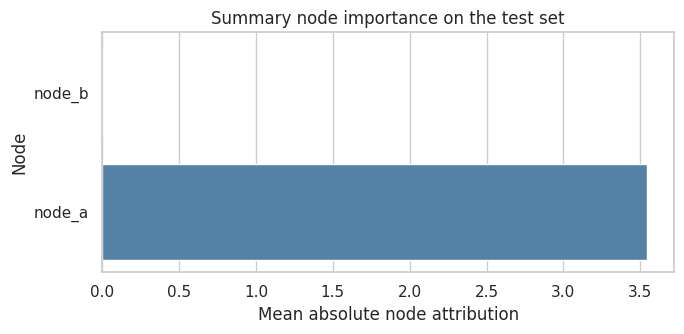

In [11]:
summary_a_only = (
    node_importance.abs()
    .mean(axis=0)
    .sort_values(ascending=True)
    .rename("mean_abs_attribution")
    .reset_index()
    .rename(columns={"index": "node"})
)

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=summary_a_only,
    x="mean_abs_attribution",
    y="node",
    color="steelblue",
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Summary node importance on the test set")
plt.tight_layout()
plt.show()

## Positive and negative controls

The walkthrough above recovers importance on `node_a` when only
`input_signal` is informative, while `node_b` stays near zero. That
contrast is useful, but incomplete: it does not show what happens when
the other input carries signal, when both do, or when neither does.

Hidden nodes and the output stay fixed. Each case rebuilds the edgelist
and names inputs by role:

| Case | Input → `node_a` | Input → `node_b` | Expected |
| --- | --- | --- | --- |
| A only | `input_signal` | `input_noise` | `a` high, `b` ~0 |
| Both | `input_signal_a` | `input_signal_b` | both high |
| B only | `input_noise` | `input_signal` | both high |
| Neither | `input_noise_a` | `input_noise_b` | both ~0 |

A only reuses the walkthrough results above. The remaining cases use
`steps=3` so the feedback path
`input → node_b → node_a → output` can reach the output. Code is
omitted; each case shows the graph, training loss, and node importance
on a shared attribution axis.

In [12]:
def plot_graph(edgelist, input_a, input_b):
    """Draw the cyclic graph in a fixed layout."""
    # Same construction as the main walkthrough so every
    # control figure has identical geometry; only names change.
    dot = Digraph()
    dot.attr(rankdir="LR")

    input_nodes = [input_a, input_b]
    state_nodes = ["node_a", "node_b"]
    output_nodes = ["output"]

    for node_name in input_nodes:
        dot.node(node_name, node_name)

    for node_name in state_nodes:
        dot.node(node_name, node_name)

    for node_name in output_nodes:
        dot.node(node_name, node_name)

    for row in edgelist.itertuples(index=False):
        dot.edge(str(row.source), str(row.target))

    return dot


def make_edgelist(input_a, input_b):
    """Build the fixed cyclic architecture with named inputs."""
    return pd.DataFrame(
        {
            "source": [
                input_a,
                input_b,
                "node_a",
                "node_b",
                "node_a",
            ],
            "target": [
                "node_a",
                "node_b",
                "node_b",
                "node_a",
                "output",
            ],
        }
    )


def run_state_update_case(
    edgelist,
    informative_features,
    seed,
    steps=3,
    n_epochs=100,
):
    """Compile, simulate, train, and summarize one control case."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    model, artifact = e2t.compile_graph(
        edgelist=edgelist,
        backend="state_update",
        steps=steps,
        quiet=True,
    )

    x_train_df, y_train = simulate_binary_data(
        n_per_class=80,
        feature_names=artifact.feature_names,
        informative_features=informative_features,
        rng=rng,
    )
    x_test_df, y_test = simulate_binary_data(
        n_per_class=40,
        feature_names=artifact.feature_names,
        informative_features=informative_features,
        rng=rng,
    )

    x_train = e2t.align_features_to_input_nodes(
        data=x_train_df,
        artifact=artifact,
    )

    customized_model = e2t.customize_model(
        model=model,
        head=nn.Linear(1, 1),
    )

    y_train_tensor = torch.tensor(
        y_train.values.reshape(-1, 1),
        dtype=torch.float32,
    )

    optimizer = torch.optim.Adam(
        customized_model.parameters(),
        lr=1e-2,
    )
    loss_fn = nn.BCEWithLogitsLoss()
    loss_history = []

    customized_model.train()
    for _ in range(n_epochs):
        optimizer.zero_grad()
        logits = customized_model(x_train)
        loss = loss_fn(logits, y_train_tensor)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    customized_model.eval()
    node_importance_case = e2t.interpret_model(
        model=customized_model,
        artifact=artifact,
        data=x_test_df,
        target="nodes",
        method="LayerConductance",
        quiet=True,
    )

    summary = (
        node_importance_case.abs()
        .mean(axis=0)
        .sort_values(ascending=True)
        .rename("mean_abs_attribution")
        .reset_index()
        .rename(columns={"index": "node"})
    )

    return {
        "loss_history": loss_history,
        "summary": summary,
    }


def plot_case_results(case_name, result, attr_xlim=None):
    """Plot training loss and node-importance summary."""
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 3.5),
        gridspec_kw={"width_ratios": [1.1, 1.0]},
    )

    axes[0].plot(
        range(1, len(result["loss_history"]) + 1),
        result["loss_history"],
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy loss")
    axes[0].set_title(f"{case_name}: training loss")

    sns.barplot(
        data=result["summary"],
        x="mean_abs_attribution",
        y="node",
        color="steelblue",
        ax=axes[1],
    )
    axes[1].set_xlabel("Mean absolute node attribution")
    axes[1].set_ylabel("Node")
    axes[1].set_title(f"{case_name}: node importance")
    if attr_xlim is not None:
        axes[1].set_xlim(attr_xlim)

    fig.tight_layout()
    plt.show()


# A-only: reuse the main walkthrough graph and results.
graph_a_only = plot_graph(
    edgelist,
    "input_signal",
    "input_noise",
)
result_a_only = {
    "loss_history": loss_history,
    "summary": summary_a_only,
}

edgelist_both = make_edgelist(
    "input_signal_a",
    "input_signal_b",
)
edgelist_b_only = make_edgelist(
    "input_noise",
    "input_signal",
)
edgelist_neither = make_edgelist(
    "input_noise_a",
    "input_noise_b",
)

graph_both = plot_graph(
    edgelist_both,
    "input_signal_a",
    "input_signal_b",
)
graph_b_only = plot_graph(
    edgelist_b_only,
    "input_noise",
    "input_signal",
)
graph_neither = plot_graph(
    edgelist_neither,
    "input_noise_a",
    "input_noise_b",
)

result_both = run_state_update_case(
    edgelist=edgelist_both,
    informative_features=[
        "input_signal_a",
        "input_signal_b",
    ],
    seed=1,
)
result_b_only = run_state_update_case(
    edgelist=edgelist_b_only,
    informative_features=["input_signal"],
    seed=2,
)
result_neither = run_state_update_case(
    edgelist=edgelist_neither,
    informative_features=[],
    seed=3,
)

xmax = max(
    result_a_only["summary"]["mean_abs_attribution"].max(),
    result_both["summary"]["mean_abs_attribution"].max(),
    result_b_only["summary"]["mean_abs_attribution"].max(),
    result_neither["summary"]["mean_abs_attribution"].max(),
)
attr_xlim = (0, float(xmax) * 1.05)

### Case: A only

Only the input to `node_a` (`input_signal`) is informative. The input
to `node_b` is `input_noise`. Results are taken from the walkthrough
above.

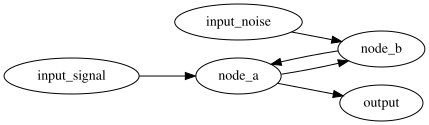

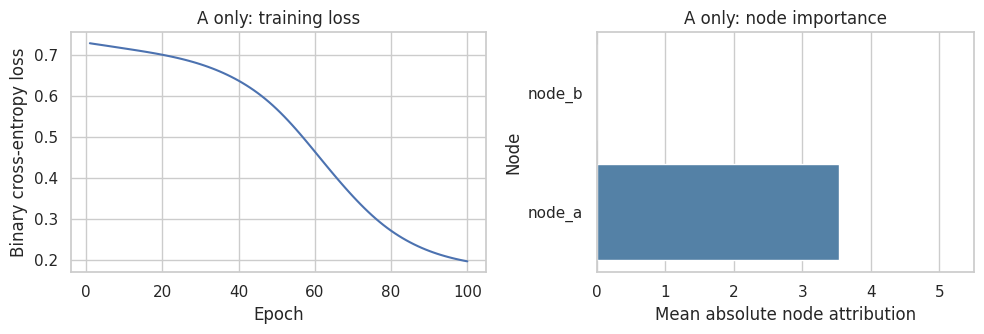

In [13]:
display(graph_a_only)
plot_case_results("A only", result_a_only, attr_xlim)

### Case: both inputs informative

Both inputs carry class signal (`input_signal_a` → `node_a`,
`input_signal_b` → `node_b`). Both hidden nodes should receive
importance.

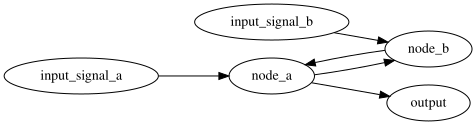

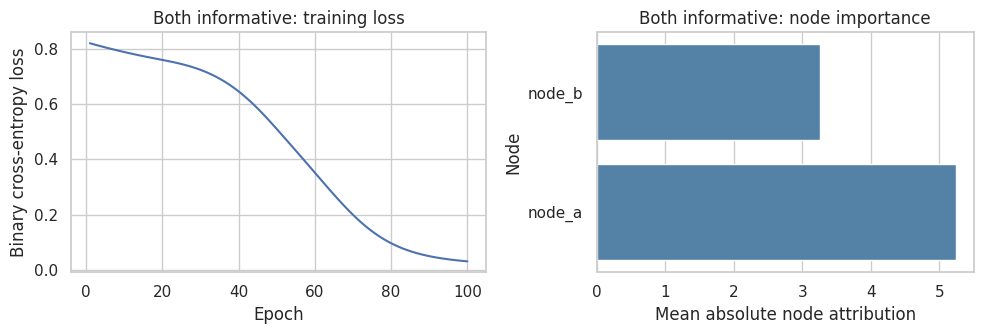

In [14]:
display(graph_both)
plot_case_results("Both informative", result_both, attr_xlim)

### Case: B only

Only the input to `node_b` (`input_signal`) is informative. The input
to `node_a` is `input_noise`. Because only `node_a` connects to
`output`, the path
`input_signal → node_b → node_a → output` must carry the signal.
Both hidden nodes should therefore receive importance.

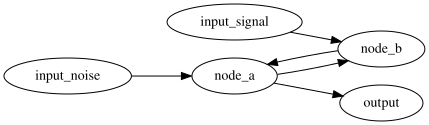

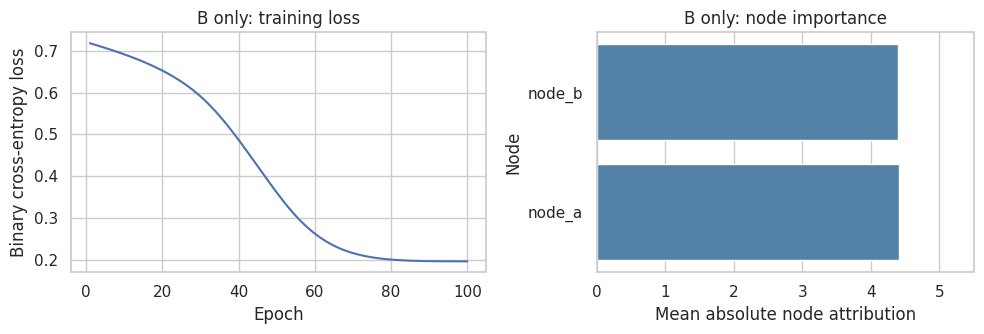

In [15]:
display(graph_b_only)
plot_case_results("B only", result_b_only, attr_xlim)

### Case: neither input informative

Both inputs are uninformative (`input_noise_a`, `input_noise_b`).
The model should not recover strong, consistent importance on either
hidden node.

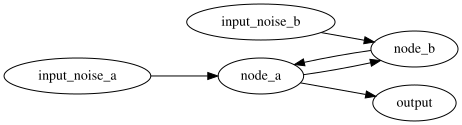

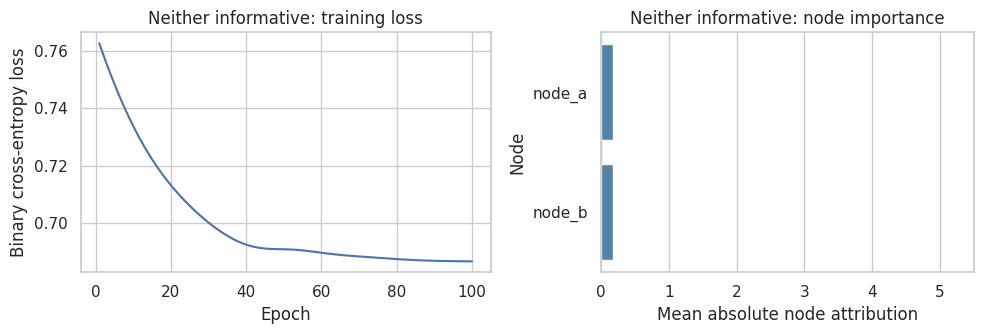

In [16]:
display(graph_neither)
plot_case_results("Neither informative", result_neither, attr_xlim)

### Control summary

Across the four cases:

- **A only** (`input_signal` / `input_noise`): importance concentrates
  on `node_a`; `node_b` stays near zero
- **Both** (`input_signal_a` / `input_signal_b`): both hidden nodes
  receive importance
- **B only** (`input_noise` → `node_a`, `input_signal` → `node_b`):
  loss decreases and both hidden nodes receive importance via the
  feedback path to the output
- **Neither** (`input_noise_a` / `input_noise_b`): loss remains near
  chance; neither hidden node shows strong recovered importance

Low importance on `node_b` in the A-only setting therefore reflects its
uninformative input. Recovering importance through the feedback path
also requires enough unrolled steps for
`input → node_b → node_a → output` to reach the output.